# 01 Generate Derivative Data

Ovaj notebook pravi podatke oblika `(x, xdot)` za učenje kontinualne dinamike fizičkog sistema.

- `x` je trenutno stanje sistema.
- `xdot = f(x)` je vremenski izvod stanja, tj. vektorsko polje sistema.
- Stabilni ICNN model iz narednog notebooka uči upravo mapiranje `x -> xdot`.

Podrazumevano je izabran prigušeni harmonijski oscilator, jer je dvodimenzionalan i lako se vizuelizuje. Isti kod možeš prebaciti na klatno promenom konfiguracione ćelije.

## 1. Importi i konfiguracija

Ova ćelija radi dve stvari:

1. Dodaje root repozitorijuma u `sys.path`, tako da notebook može da importuje lokalni paket i kada je Jupyter pokrenut iz foldera `notebooks/`.
2. Bira fizički sistem i broj uzoraka za train/test skup.

Za oscilator je stanje `x = [position, velocity]`, a izvod je `xdot = [velocity, acceleration]`.
Za jedno klatno je stanje `x = [theta, omega]`, a izvod je `xdot = [omega, angular_acceleration]`.

In [21]:
from pathlib import Path
import sys
import numpy as np

# Let the notebook import the local package whether Jupyter starts in the
# repository root or inside the notebooks/ directory.
REPO_ROOT = Path.cwd() if (Path.cwd() / "stable_icnn_physics").exists() else Path.cwd().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Jupyter kernels keep imported modules in memory. If package code changed
# while the kernel was alive, clear the local package so imports see the
# latest files from disk.
for module_name in list(sys.modules):
    if module_name == "stable_icnn_physics" or module_name.startswith("stable_icnn_physics."):
        del sys.modules[module_name]

from stable_icnn_physics import DampedPendulum, MassSpringDamper, VanDerPolOscillator
from stable_icnn_physics.data import dataset_path, generate_derivative_data, save_dataset

CACHE_DIR = REPO_ROOT / "data/cache"
SEED = 0
N_TRAIN = 4000
N_TEST = 1000

# Choose one system by uncommenting/editing.
# SYSTEM_NAME = "pendulum1"
# system = DampedPendulum(n_links=1, friction=0.3, gravity=9.81)

#SYSTEM_NAME = "oscillator"
#system = MassSpringDamper(mass=1.0, damping=0.3, stiffness=1.0)

# Nonlinear benchmark with a stable limit cycle.
# Important: the stable ICNN model is globally stable to the origin, so Van der Pol
# is also a useful test of this model class's limitations.
SYSTEM_NAME = "vanderpol_mu1"
system = VanDerPolOscillator(mu=1.0)

print(f"System: {SYSTEM_NAME}")
print(f"State dimension: {system.state_dim}")

System: vanderpol_mu1
State dimension: 2


## 2. Generisanje derivative dataset-a

Ovde slučajno uzorkujemo stanja iz domena sistema i za svako stanje računamo tačan izvod `xdot` pomoću matematičkog modela.

To je paper-faithful režim za fizičke sisteme: mreža ne uči direktno `x_t -> x_{t+1}`, nego kontinualno vektorsko polje `f(x)`. Kasnije se naučena dinamika može integrisati numerički, npr. RK4 metodom.

In [22]:
generated = {}

for split, n_samples in [("train", N_TRAIN), ("test", N_TEST)]:
    x, y = generate_derivative_data(system, n_samples=n_samples, split=split, seed=SEED)
    path = dataset_path(CACHE_DIR, SYSTEM_NAME, split, n_samples, SEED)
    save_dataset(path, x, y, metadata={"system": SYSTEM_NAME, "split": split, "seed": SEED})
    generated[split] = (x, y, path)
    print(path)
    print("  x shape:", x.shape, "xdot shape:", y.shape)
    print("  finite:", np.isfinite(x).all() and np.isfinite(y).all())

x, y, train_path = generated["train"]

/media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN/data/cache/vanderpol_mu1_train_n4000_seed0.npz
  x shape: (4000, 2) xdot shape: (4000, 2)
  finite: True
/media/ognjen/T7 Shield/DOCs, PDFs/018 Master/DeepLearningFTN/data/cache/vanderpol_mu1_test_n1000_seed0.npz
  x shape: (1000, 2) xdot shape: (1000, 2)
  finite: True


## 3. Raspodela uzorkovanih stanja

Ovaj scatter plot prikazuje gde se nalaze stanja koja šaljemo mreži tokom treninga.

Za oscilator osa `state[0]` je položaj, a `state[1]` brzina. Za klatno su to ugao i ugaona brzina.

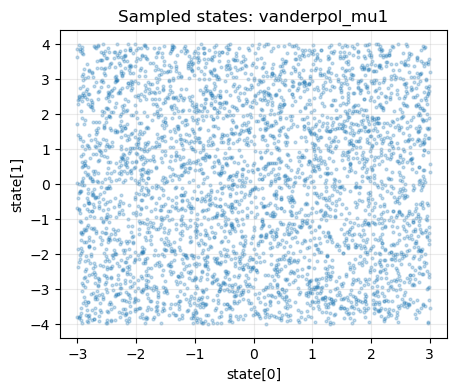

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
plt.scatter(x[:, 0], x[:, 1], s=4, alpha=0.25)
plt.xlabel("state[0]")
plt.ylabel("state[1]")
plt.title(f"Sampled states: {SYSTEM_NAME}")
plt.grid(alpha=0.25);

## 4. Simulirane trajektorije oscilatora

Sledeće ćelije nisu potrebne za čuvanje dataset-a, ali su korisne za proveru intuicije.

Za prigušeni oscilator očekujemo spirale u faznom prostoru: energija opada zbog damping člana, pa se putanje približavaju ravnoteži `(position, velocity) = (0, 0)`.

Ako prebaciš `system` na klatno, ove ćelije će se preskočiti ili će tražiti malu adaptaciju osa.

In [24]:
from stable_icnn_physics.eval import rollout_system

if not isinstance(system, MassSpringDamper):
    print("Trajectory visualization below is configured for MassSpringDamper. Current system:", type(system).__name__)
else:
    DT = 0.03
    STEPS = 260
    N_TRAJECTORIES = 6

    x0 = system.sample_states(N_TRAJECTORIES, split="test", seed=SEED + 123)
    true_traj = rollout_system(system, x0, steps=STEPS, dt=DT)
    time = np.arange(STEPS + 1) * DT

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for i in range(N_TRAJECTORIES):
        axes[0].plot(true_traj[:, i, 0], true_traj[:, i, 1], lw=1.5, label=f"traj {i + 1}")
        axes[0].scatter(true_traj[0, i, 0], true_traj[0, i, 1], s=20)
        axes[1].plot(time, true_traj[:, i, 0], lw=1.3)

    axes[0].scatter([0], [0], c="black", s=35, marker="x", label="equilibrium")
    axes[0].set_xlabel("position")
    axes[0].set_ylabel("velocity")
    axes[0].set_title("Phase-space trajectories")
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=8)

    axes[1].set_xlabel("time")
    axes[1].set_ylabel("position")
    axes[1].set_title("Position over time")
    axes[1].grid(alpha=0.25)

    plt.tight_layout()

Trajectory visualization below is configured for MassSpringDamper. Current system: VanDerPolOscillator


## 5. Animacija jednog kretanja

Animacija ispod prikazuje položaj mase na opruzi. Matematički model je i dalje isti kao u dataset-u:

\[
\dot{x}_1 = x_2, \qquad
\dot{x}_2 = -
rac{k}{m}x_1 - 
rac{c}{m}x_2.
\]

Drugim rečima, masa se kreće levo-desno, dok damping postepeno smanjuje amplitudu oscilovanja.

In [25]:
from IPython.display import HTML, display
from matplotlib import animation

if not isinstance(system, MassSpringDamper):
    print("Animation is configured for MassSpringDamper. Current system:", type(system).__name__)
else:
    DT = 0.03
    STEPS = 220
    x0_anim = np.array([[1.8, 0.0]], dtype=np.float32)
    anim_traj = rollout_system(system, x0_anim, steps=STEPS, dt=DT)[:, 0, :]

    fig, ax = plt.subplots(figsize=(7, 2.5))
    ax.set_xlim(-2.4, 2.4)
    ax.set_ylim(-0.8, 0.8)
    ax.set_xlabel("position")
    ax.set_yticks([])
    ax.set_title("Damped mass-spring oscillator")
    ax.grid(axis="x", alpha=0.2)

    wall = ax.axvline(-2.2, color="black", lw=3)
    equilibrium = ax.axvline(0.0, color="gray", lw=1, ls="--", alpha=0.7)
    spring_line, = ax.plot([], [], color="tab:blue", lw=2)
    mass_marker, = ax.plot([], [], "s", color="tab:red", markersize=18)
    time_text = ax.text(0.02, 0.88, "", transform=ax.transAxes)

    def spring_points(x_pos, coils=16):
        left = -2.2
        right = x_pos
        xs = np.linspace(left, right, coils * 2 + 1)
        ys = np.zeros_like(xs)
        if len(xs) > 2:
            ys[1:-1:2] = 0.18
            ys[2:-1:2] = -0.18
        return xs, ys

    def init():
        spring_line.set_data([], [])
        mass_marker.set_data([], [])
        time_text.set_text("")
        return spring_line, mass_marker, time_text

    def update(frame):
        pos, vel = anim_traj[frame]
        sx, sy = spring_points(pos)
        spring_line.set_data(sx, sy)
        mass_marker.set_data([pos], [0.0])
        time_text.set_text(f"t = {frame * DT:.2f}s,  x = {pos:.2f},  v = {vel:.2f}")
        return spring_line, mass_marker, time_text

    anim = animation.FuncAnimation(
        fig,
        update,
        init_func=init,
        frames=len(anim_traj),
        interval=30,
        blit=True,
    )
    plt.close(fig)
    display(HTML(anim.to_jshtml()))

Animation is configured for MassSpringDamper. Current system: VanDerPolOscillator
